### Visually Exploring a Data Set

1. Load & Inspect

In [ ]:
#Visually Exploring a Data Set#

#1. Load & Inspect#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os


sns.set(style="darkgrid")
plt.rcParams['figure.dpi'] = 110
OUT = "output"
os.makedirs(OUT, exist_ok=True)

csv_path = r"C:\Users\raynu\Desktop\Data Analysis and Visualitation\superstore.csv"
df = pd.read_csv(csv_path)
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print ('Shape:', df.shape)
print ('\nCategory counts:\n', df['Category'].value_counts())
print ('\nRegion counts:\n', df['Region'].value_counts())
print ('Exists:', csv_path)
df.head()

Shape: (9994, 13)

Category counts:
 Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Region counts:
 Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Exists: C:\Users\raynu\Desktop\Data Analysis and Visualitation\superstore.csv


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2.0,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3.0,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2.0,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5.0,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2.0,0.20,2.52


### 2.Descriptive Statistics


In [ ]:
location = df[numeric_cols].agg(['mean', 'median']).T
location ['mode']= df[numeric_cols].mode().iloc[0]
print ( '==LOCATION==')
print (location.round(3))

==LOCATION==
             mean  median   mode
Sales     229.858  54.490  12.96
Quantity    3.790   3.000   3.00
Discount    0.156   0.200   0.00
Profit     28.657   8.665   0.00


In [19]:
variance = pd.DataFrame({
    "std": df[numeric_cols].std(),
    "variance": df[numeric_cols].var(),
    "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
    "range": df[numeric_cols].max() - df[numeric_cols].min()
})
print("=== VARIANCE / SPREAD ===")
print(variance.round(3))

=== VARIANCE / SPREAD ===
              std    variance     IQR     range
Sales     623.245  388434.493  192.66  22638.04
Quantity    2.225       4.951    3.00     13.00
Discount    0.206       0.043    0.20      0.80
Profit    234.260   54877.843   27.63  14999.96


In [20]:
shape = pd.DataFrame({
    "skewness": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurt()
})
print("=== DISTRIBUTION SHAPE ===")
print(shape.round(3))

=== DISTRIBUTION SHAPE ===
          skewness  kurtosis
Sales       12.973   305.312
Quantity     1.279     1.992
Discount     1.684     2.410
Profit       7.561   397.188


In [22]:
corr_matrix = df[numeric_cols].corr(method="pearson")
print("=== CORRELATION MATRIX ===")
print(corr_matrix.round(3))

=== CORRELATION MATRIX ===
          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000


### 3. Iterative Visualization

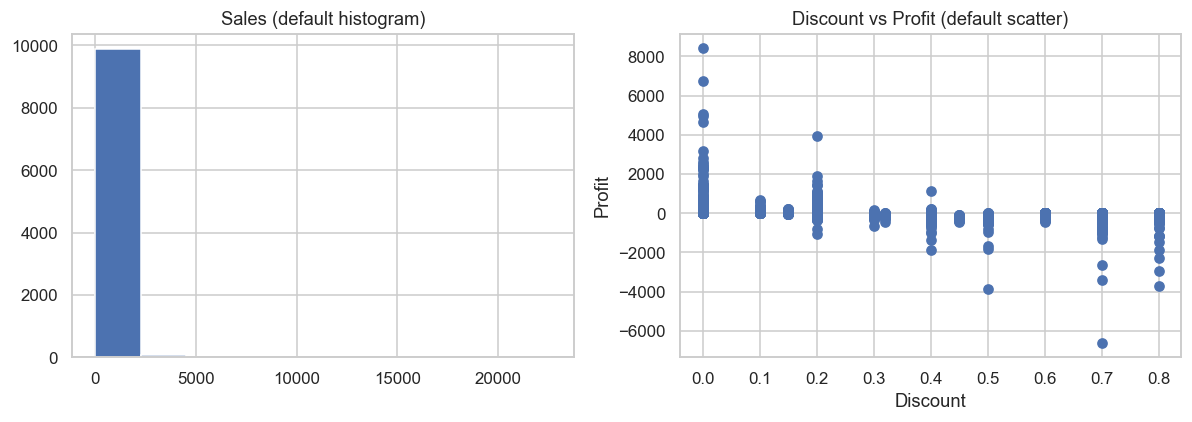

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Sales"])
axes[0].set_title("Sales (default histogram)")
axes[1].scatter(df["Discount"], df["Profit"])
axes[1].set_title("Discount vs Profit (default scatter)")
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Profit")
plt.tight_layout()
plt.savefig(OUT + "round1_baseline.png")
plt.show()

### 4.Refined distributions

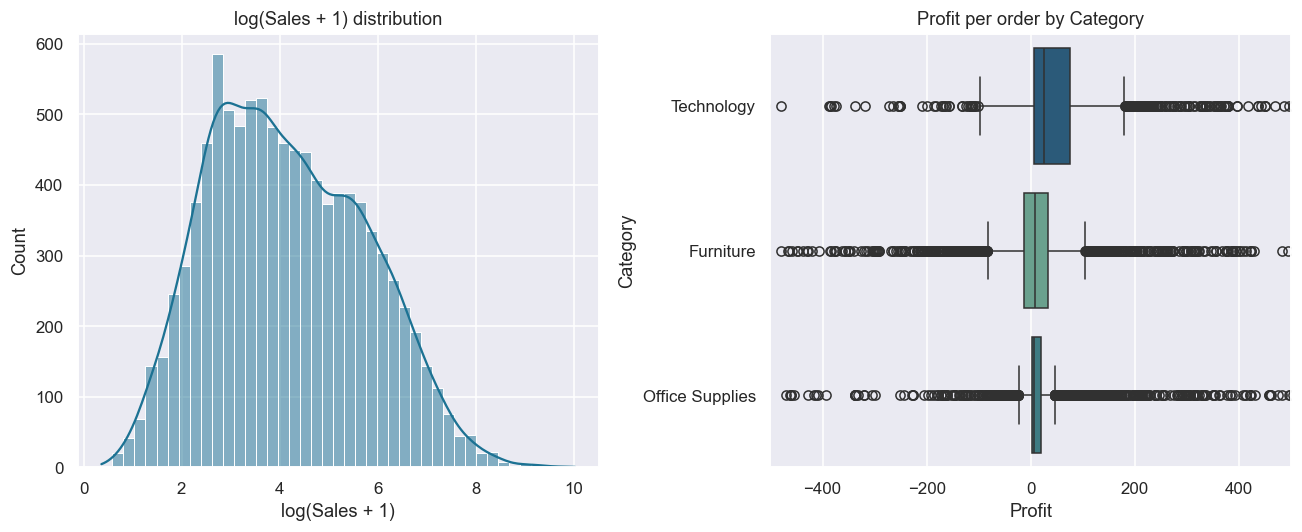

In [29]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(np.log1p(df["Sales"]), kde=True, color="#1C7293", ax=axes[0])
axes[0].set_title("log(Sales + 1) distribution")
axes[0].set_xlabel("log(Sales + 1)")

order = df.groupby("Category")["Profit"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Profit", y="Category", order=order,
            hue="Category", palette="crest", legend=False, ax=axes[1])
axes[1].set_xlim(-500, 500)
axes[1].set_title("Profit per order by Category")

plt.tight_layout()
plt.savefig(OUT + "round2_distributions.png")
plt.show()

### 5. Correlation structure

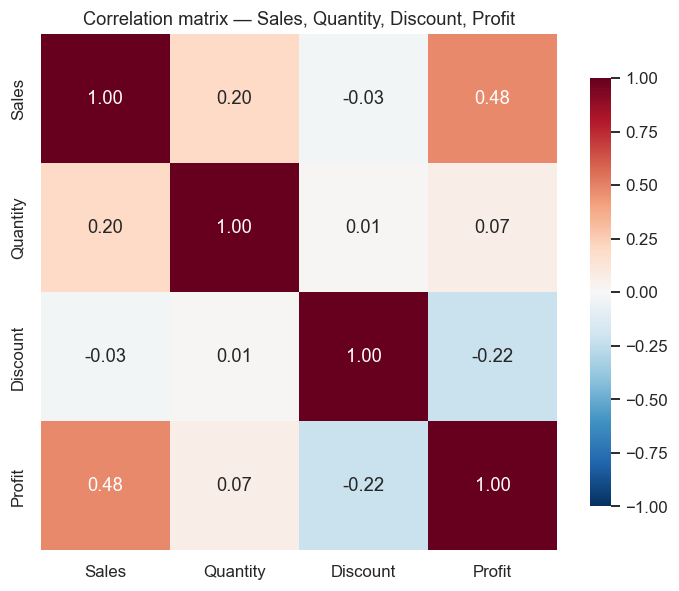

In [34]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — Sales, Quantity, Discount, Profit")

plt.tight_layout()
plt.savefig(OUT + "round3_correlation_heatmap.png")
plt.show()

Least profitable sub-categories:
              total_sales  total_profit  avg_discount
Sub_Category                                         
Tables          206965.68     -17725.59          0.26
Bookcases       114880.05      -3472.56          0.21
Supplies         46673.52      -1188.99          0.08
Fasteners         3024.25        949.53          0.08
Machines        189238.68       3384.73          0.31

Most profitable sub-categories:
              total_sales  total_profit  avg_discount
Sub_Category                                         
Binders         203412.77      30221.64          0.37
Paper            78479.24      34053.34          0.07
Accessories     167380.31      41936.78          0.08
Phones          330007.10      44516.25          0.15
Copiers         149528.01      55617.90          0.16


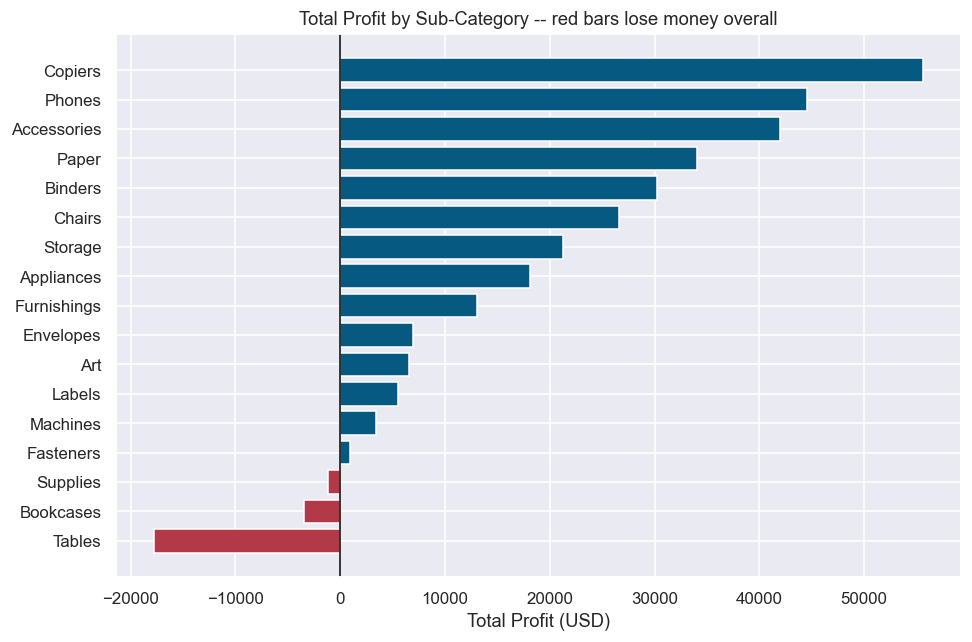

In [35]:
sub_summary = df.groupby("Sub_Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_discount=("Discount", "mean")
).sort_values("total_profit")

print("Least profitable sub-categories:")
print(sub_summary.head(5).round(2))
print("\nMost profitable sub-categories:")
print(sub_summary.tail(5).round(2))

fig, ax = plt.subplots(figsize=(9, 6))
colors = sub_summary["total_profit"].apply(lambda v: "#B23A48" if v < 0 else "#065A82")
ax.barh(sub_summary.index, sub_summary["total_profit"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Total Profit by Sub-Category -- red bars lose money overall")
ax.set_xlabel("Total Profit (USD)")
plt.tight_layout()
plt.savefig(OUT + "round4_subcategory_profit.png")
plt.show()